In [8]:
from PIL import Image
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from numpy import *

In [23]:
def compute_harris(im,sigma=3):
    imx = zeros(im.shape)
    gaussian_filter(im,(sigma,sigma),(0,1),imx)
    imy = zeros(im.shape)
    gaussian_filter(im,(sigma,sigma),(1,0),imy)

    Wxx = gaussian_filter(imx*imx,sigma)
    Wxy = gaussian_filter(imx*imy,sigma)
    Wyy = gaussian_filter(imy*imy, sigma)

    Wdet = Wxx*Wyy - Wxy**2
    Wtr = Wxx +Wyy

    return Wdet / Wtr


In [18]:
def get_harris_points(harrisim, min_dist=10,threshold=0.1):
    corner_threshold = harrisim.max() * threshold
    harrisim_t = (harrisim>corner_threshold) * 1


    coords = np.array(harrisim_t.nonzero()).T

    candidate_values = [harrisim[c[0],c[1]] for c in coords]


    index = np.argsort(candidate_values)

    allowed_locations = np.zeros(harrisim.shape)
    allowed_locations[min_dist:-min_dist,min_dist:-min_dist] = 1


    filtered_coords = []
    for i in index:
        if allowed_locations[coords[i,0],coords[i,1]] == 1:
            filtered_coords.append(coords[i])
            allowed_locations[(coords[i,0]-min_dist):(coords[i,0]+min_dist),
                    (coords[i,1]-min_dist):(coords[i,1]+min_dist)] = 0

    return filtered_coords



In [14]:
def get_descriptor(image, filtered_cords,wid=5):

  desc=[]

  for cords in filtered_cords:
    patch = image[cords[0]-wid:cords[0]+1+wid,
                  cords[1]-wid:cords[1]+1+wid].flatten()
    desc.append(patch)

  return desc

In [15]:
def match(desc1,desc2,threshold=0.5):
  n= len(desc1[0])

  d = -ones((len(desc1),len(desc2)))

  for i in range(len(desc1)):
    for j in range(len(desc2)):
      d1 = (desc1[i] - mean(desc1[i]))
      d2 = (desc2[j] - mean(desc2[j]))
      ncc_value = sum(d1*d2) / (n-1)
      if ncc_value > threshold:
        d[i,j] = ncc_value
  ndx = argsort(-d)
  matchscore = ndx[:,0]
  return matchscore

In [16]:
def match_twosided(desc1, desc2, threshold=0.5):

  match_12 = match(desc1, desc2, threshold)
  match_21 = match(desc2, desc1, threshold)

  ndx_12 = where(match_12>=0)[0]

  for n in ndx_12:
    if match_21[match_12[n]] != n:
      match_12[n] = -1
  return match_12

In [17]:
def appendimages(im1,im2):
  """ Return a new image that appends the two images side-by-side. """

  # select the image with the fewest rows and fill in enough empty rows
  rows1 = im1.shape[0]
  rows2 = im2.shape[0]

  if rows1 < rows2:
    im1 = concatenate((im1,zeros((rows2-rows1,im1.shape[1]))),axis=0)
  elif rows1 > rows2:
    im2 = concatenate((im2,zeros((rows1-rows2,im2.shape[1]))),axis=0)
  # if none of these cases they are equal, no filling needed.

  return concatenate((im1,im2), axis=1)


def plot_matches(im1,im2,locs1,locs2,matchscores,show_below=True):
  """ Show a figure with lines joining the accepted matches
    input: im1,im2 (images as arrays), locs1,locs2 (feature locations),
    matchscores (as output from 'match()'),
    show_below (if images should be shown below matches). """

  im3 = appendimages(im1,im2)
  if show_below:
    im3 = vstack((im3,im3))

  plt.imshow(im3)

  cols1 = im1.shape[1]
  for i,m in enumerate(matchscores):
    if m>0:
      plt.plot([locs1[i][1],locs2[m][1]+cols1],[locs1[i][0],locs2[m][0]],'c')
  plt.axis('off')

In [19]:
def plot_harris_points(image,filtered_coords):
  """ Plots corners found in image. """

  plt.figure()
  plt.gray()
  plt.imshow(image)
  plt.plot([p[1] for p in filtered_coords],[p[0] for p in filtered_coords],'*')
  plt.axis('off')
  plt.show()

In [30]:
def get_harris_points(harrisim, min_dist=10,threshold=0.1):
    corner_threshold = harrisim.max() * threshold
    harrisim_t = (harrisim>corner_threshold) * 1


    coords = np.array(harrisim_t.nonzero()).T

    candidate_values = [harrisim[c[0],c[1]] for c in coords]


    index = np.argsort(candidate_values)

    allowed_locations = np.zeros(harrisim.shape)
    allowed_locations[min_dist:-min_dist,min_dist:-min_dist] = 1


    filtered_coords = []
    for i in index:
        if allowed_locations[coords[i,0],coords[i,1]] == 1:
            filtered_coords.append(coords[i])
            allowed_locations[(coords[i,0]-min_dist):(coords[i,0]+min_dist),
                    (coords[i,1]-min_dist):(coords[i,1]+min_dist)] = 0

    return filtered_coords


starting matching


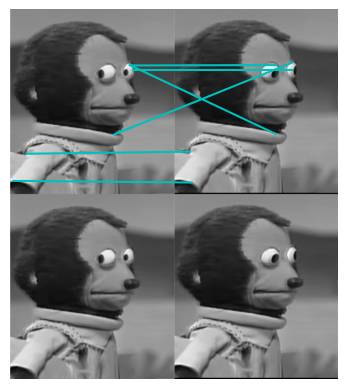

In [32]:
wid = 5
im1 = array(Image.open('img1.png').convert('L'))
harrisim = compute_harris(im1,5)
filterd_coords1 = get_harris_points(harrisim,wid+1)
d1 = get_descriptor(im1,filterd_coords1,wid)


im2 = array(Image.open('img2.png').convert('L'))
harrisim = compute_harris(im2,5)
filterd_coords2 = get_harris_points(harrisim,wid+1)
d2 = get_descriptor(im2,filterd_coords2,wid)


print('starting matching')
matches = match_twosided(d1,d2)

plt.figure()
plt.gray()
plot_matches(im1,im2,filterd_coords1,filterd_coords2,matches)
plt.show()